# 02 — DINOv2 and CLIP Feature Exploration

## Goal

This notebook verifies the two frozen foundation models that will later be used
for text-conditioned part segmentation.

### DINOv2
- Input: RGB image
- Output: dense patch-level visual features
- Backbone: DINOv2 ViT-S/14
- Expected feature dimension: 384
- Expected spatial grid at 224 × 224: 16 × 16

### CLIP
- Input: textual part query such as `"wheel"`
- Output: semantic text embedding
- Backbone: CLIP ViT-B/32 text encoder
- Expected embedding dimension: 512

## Important

This notebook does NOT implement:

- segmentation decoder
- model training
- object-mask conditioning
- absolute X/Y coordinates
- object-relative U/V coordinates
- DINO–CLIP alignment
- rotation experiments
- noisy-mask experiments

The purpose is to understand and validate DINOv2 and CLIP independently
before combining them.

In [1]:
%pip install -q open_clip_torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

import open_clip

In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

# Make sure our local `datasets/` package is found
# before any externally installed package called `datasets`.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [4]:
from datasets import PascalPart116Dataset

print("PascalPart116Dataset imported successfully.")

PascalPart116Dataset imported successfully.


In [5]:
SEED = 42

IMAGE_SIZE = 224

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Image size:", IMAGE_SIZE)

Device: cuda
Image size: 224


In [6]:
dataset = PascalPart116Dataset(
    split="train_seen"
)

print("Number of query samples:", len(dataset))

Number of query samples: 32698


In [7]:
sample = dataset[0]

print("Sample ID:", sample["sample_id"])
print("Image ID:", sample["image_id"])

print()

print("Object:", sample["object_name"])
print("Part:", sample["part_name"])
print("Query:", sample["query"])

print()

print("Image shape:", sample["image"].shape)
print("Image dtype:", sample["image"].dtype)

print("Object mask:", sample["object_mask"].shape)
print("Part mask:", sample["part_mask"].shape)

Sample ID: train:2008_000002:part_115
Image ID: 2008_000002

Object: tvmonitor
Part: screen
Query: screen

Image shape: torch.Size([3, 375, 500])
Image dtype: torch.uint8
Object mask: torch.Size([375, 500])
Part mask: torch.Size([375, 500])


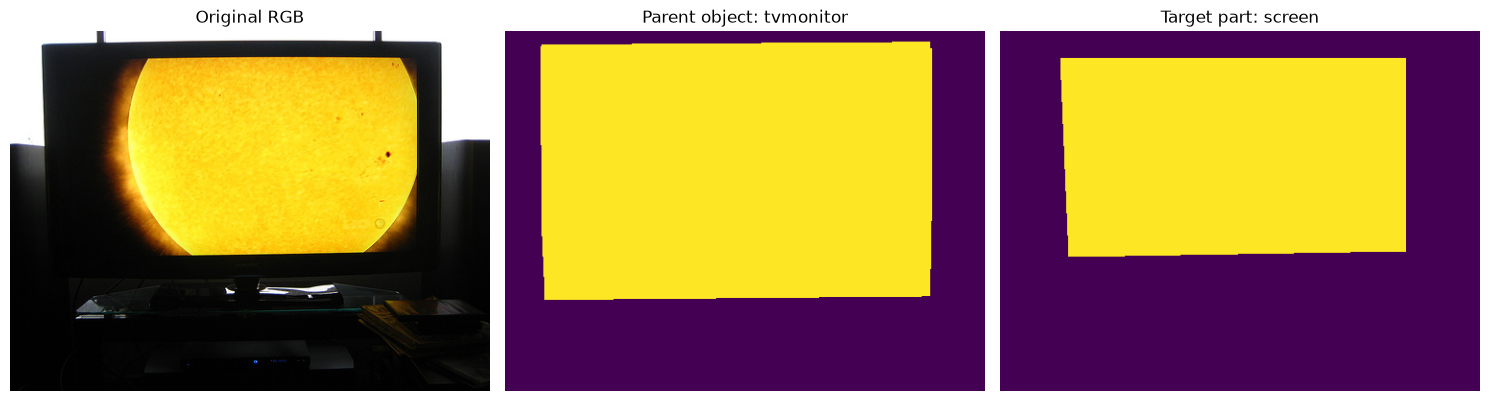

In [8]:
rgb = sample["image"].permute(1, 2, 0).numpy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(rgb)
axes[0].set_title("Original RGB")

axes[1].imshow(
    sample["object_mask"].numpy()
)
axes[1].set_title(
    f"Parent object: {sample['object_name']}"
)

axes[2].imshow(
    sample["part_mask"].numpy()
)
axes[2].set_title(
    f"Target part: {sample['part_name']}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)

In [10]:
def resize_and_pad_image(
    image,
    target_size=224,
):
    """
    Parameters
    ----------
    image:
        uint8 Tensor [3, H, W]

    Returns
    -------
    display_image:
        float32 Tensor [3, target_size, target_size]
        range approximately [0,1]

    normalized_image:
        float32 Tensor [3, target_size, target_size]
        ImageNet-normalized input for DINO

    resize_info:
        dictionary containing resize/padding information
    """

    image = image.float() / 255.0

    _, h, w = image.shape

    scale = min(
        target_size / h,
        target_size / w,
    )

    new_h = max(
        1,
        round(h * scale)
    )

    new_w = max(
        1,
        round(w * scale)
    )

    resized = TF.resize(
        image,
        [new_h, new_w],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    top = pad_h // 2
    bottom = pad_h - top

    left = pad_w // 2
    right = pad_w - left

    display_image = F.pad(
        resized,
        (left, right, top, bottom),
        value=0.0,
    )

    normalized_image = (
        display_image - IMAGENET_MEAN
    ) / IMAGENET_STD

    resize_info = {
        "original_height": h,
        "original_width": w,
        "resized_height": new_h,
        "resized_width": new_w,
        "scale": scale,
        "pad_top": top,
        "pad_bottom": bottom,
        "pad_left": left,
        "pad_right": right,
    }

    return (
        display_image,
        normalized_image,
        resize_info,
    )

In [11]:
display_image, dino_input, resize_info = (
    resize_and_pad_image(
        sample["image"],
        target_size=IMAGE_SIZE,
    )
)

print("Original:")
print(sample["image"].shape)

print("\nDisplay image:")
print(display_image.shape)
print(display_image.dtype)
print(
    display_image.min().item(),
    display_image.max().item(),
)

print("\nDINO input:")
print(dino_input.shape)
print(dino_input.dtype)

print("\nResize information:")
resize_info

Original:
torch.Size([3, 375, 500])

Display image:
torch.Size([3, 224, 224])
torch.float32
0.0 1.000000238418579

DINO input:
torch.Size([3, 224, 224])
torch.float32

Resize information:


{'original_height': 375,
 'original_width': 500,
 'resized_height': 168,
 'resized_width': 224,
 'scale': 0.448,
 'pad_top': 28,
 'pad_bottom': 28,
 'pad_left': 0,
 'pad_right': 0}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


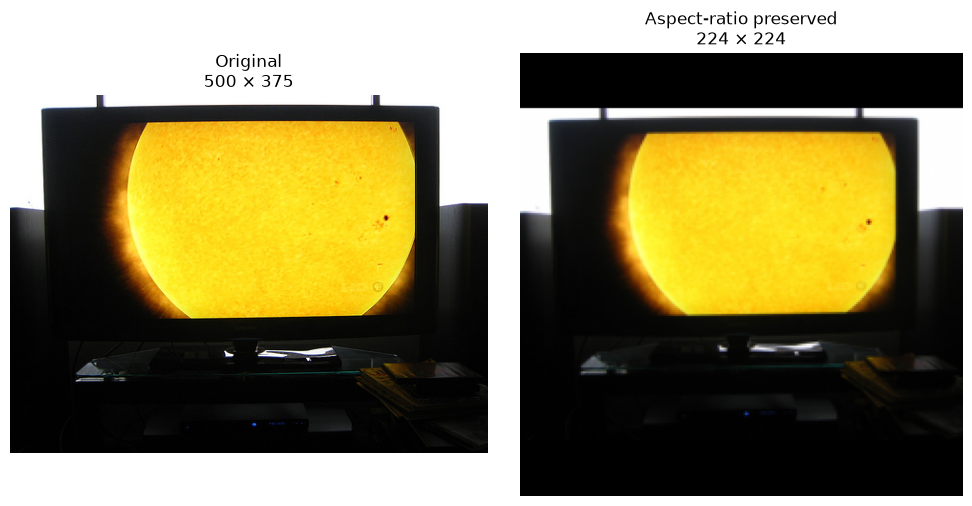

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    sample["image"]
    .permute(1, 2, 0)
    .numpy()
)

axes[0].set_title(
    f"Original\n"
    f"{sample['image'].shape[2]} × "
    f"{sample['image'].shape[1]}"
)

axes[1].imshow(
    display_image
    .permute(1, 2, 0)
    .numpy()
)

axes[1].set_title(
    "Aspect-ratio preserved\n224 × 224"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(DEVICE)
dino.eval()

for parameter in dino.parameters():
    parameter.requires_grad = False

print("DINOv2 loaded.")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /home/utn/ojug99ek/.cache/torch/hub/main.zip


/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /home/utn/ojug99ek/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:07<00:00, 11.7MB/s]


DINOv2 loaded.


In [14]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(DEVICE)
dino.eval()

for parameter in dino.parameters():
    parameter.requires_grad = False

print("DINOv2 loaded.")

Using cache found in /home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main


DINOv2 loaded.


In [15]:
total_params = sum(
    p.numel()
    for p in dino.parameters()
)

trainable_params = sum(
    p.numel()
    for p in dino.parameters()
    if p.requires_grad
)

print(
    f"Total DINO parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable DINO parameters: "
    f"{trainable_params:,}"
)

Total DINO parameters: 22,056,576
Trainable DINO parameters: 0


In [16]:
x = dino_input.unsqueeze(0).to(DEVICE)

print("Input shape:", x.shape)

Input shape: torch.Size([1, 3, 224, 224])


In [17]:
with torch.no_grad():

    dino_outputs = dino.forward_features(x)

In [18]:
for key, value in dino_outputs.items():

    if torch.is_tensor(value):
        print(
            f"{key:25s}",
            tuple(value.shape)
        )

    else:
        print(
            f"{key:25s}",
            type(value)
        )

x_norm_clstoken           (1, 384)
x_norm_regtokens          (1, 0, 384)
x_norm_patchtokens        (1, 256, 384)
x_prenorm                 (1, 257, 384)
masks                     <class 'NoneType'>


In [19]:
patch_tokens = dino_outputs[
    "x_norm_patchtokens"
]

print(
    "Patch tokens:",
    patch_tokens.shape
)

Patch tokens: torch.Size([1, 256, 384])


In [20]:
batch_size = patch_tokens.shape[0]

grid_size = IMAGE_SIZE // 14

dino_feature_map = (
    patch_tokens
    .transpose(1, 2)
    .reshape(
        batch_size,
        384,
        grid_size,
        grid_size,
    )
)

print(
    "DINO feature map:",
    dino_feature_map.shape
)

DINO feature map: torch.Size([1, 384, 16, 16])


In [21]:
row = 8
column = 8

patch_feature = dino_feature_map[
    0,
    :,
    row,
    column,
]

print(
    "One patch feature shape:",
    patch_feature.shape
)

print(
    "\nFirst 20 values:"
)

print(
    patch_feature[:20].cpu()
)

One patch feature shape: torch.Size([384])

First 20 values:
tensor([-2.5103,  2.3333, -1.0930,  0.2113,  1.6999,  0.5214,  0.3299, -3.9901,
         1.9010, -2.2257,  2.6199,  1.0886,  1.6216, -0.3561,  2.7017, -2.1580,
        -1.5357, -0.4916, -8.2238,  2.9839])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


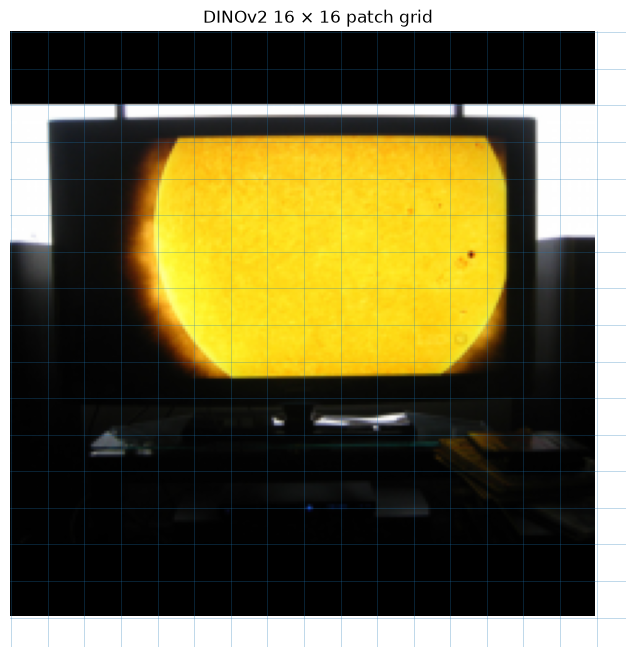

In [22]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

ax.imshow(
    display_image
    .permute(1, 2, 0)
    .numpy()
)

patch_size = 14

for pos in range(
    0,
    IMAGE_SIZE + 1,
    patch_size,
):
    ax.axhline(
        pos,
        linewidth=0.4,
        alpha=0.5,
    )

    ax.axvline(
        pos,
        linewidth=0.4,
        alpha=0.5,
    )

ax.set_title(
    "DINOv2 16 × 16 patch grid"
)

ax.axis("off")

plt.show()

In [23]:
features = (
    patch_tokens[0]
    .detach()
    .float()
    .cpu()
)

print(features.shape)

torch.Size([256, 384])


In [24]:
features_centered = (
    features
    - features.mean(
        dim=0,
        keepdim=True,
    )
)

U, S, V = torch.pca_lowrank(
    features_centered,
    q=3,
)

pca_features = (
    features_centered @ V[:, :3]
)

print(
    "PCA features:",
    pca_features.shape
)

PCA features: torch.Size([256, 3])


In [25]:
pca_vis = pca_features.clone()

for channel in range(3):

    values = pca_vis[:, channel]

    minimum = values.min()
    maximum = values.max()

    pca_vis[:, channel] = (
        values - minimum
    ) / (
        maximum - minimum + 1e-8
    )

pca_image = pca_vis.reshape(
    16,
    16,
    3,
)

print(pca_image.shape)

torch.Size([16, 16, 3])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


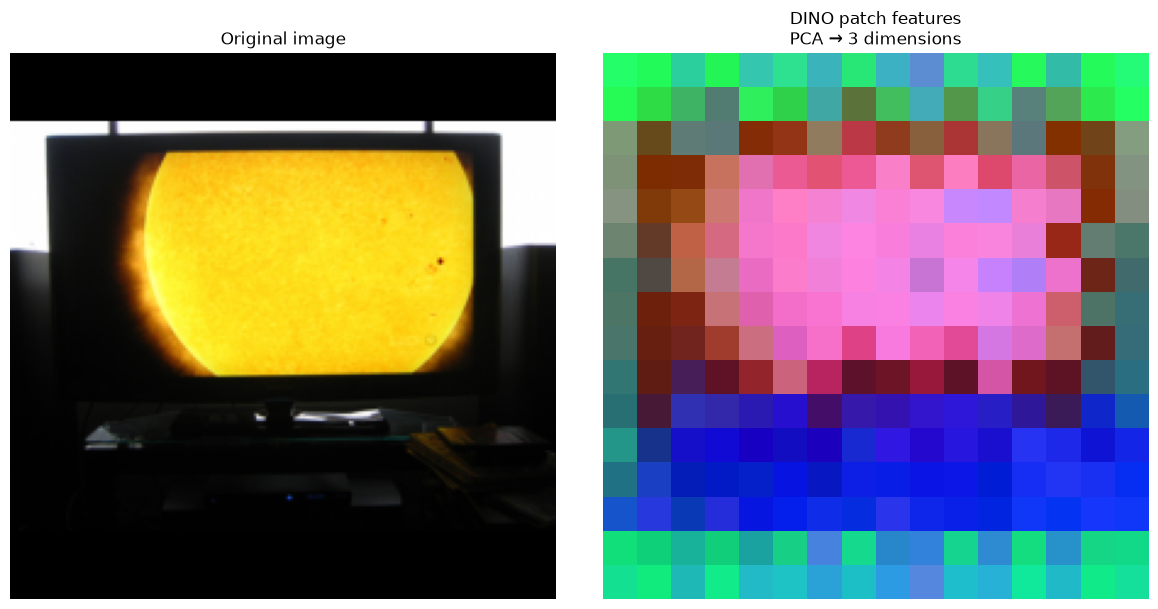

In [26]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 6)
)

axes[0].imshow(
    display_image
    .permute(1, 2, 0)
    .numpy()
)

axes[0].set_title(
    "Original image"
)

axes[1].imshow(
    pca_image.numpy()
)

axes[1].set_title(
    "DINO patch features\n"
    "PCA → 3 dimensions"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
selected_row = 8
selected_col = 8

selected_index = (
    selected_row * 16
    + selected_col
)

query_feature = features[
    selected_index
]

normalized_features = F.normalize(
    features,
    dim=-1,
)

normalized_query = F.normalize(
    query_feature.unsqueeze(0),
    dim=-1,
)

similarity = (
    normalized_features
    @ normalized_query.T
).squeeze(1)

similarity_map = similarity.reshape(
    16,
    16,
)

print(
    similarity_map.min().item(),
    similarity_map.max().item(),
)

-0.09723985195159912 1.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


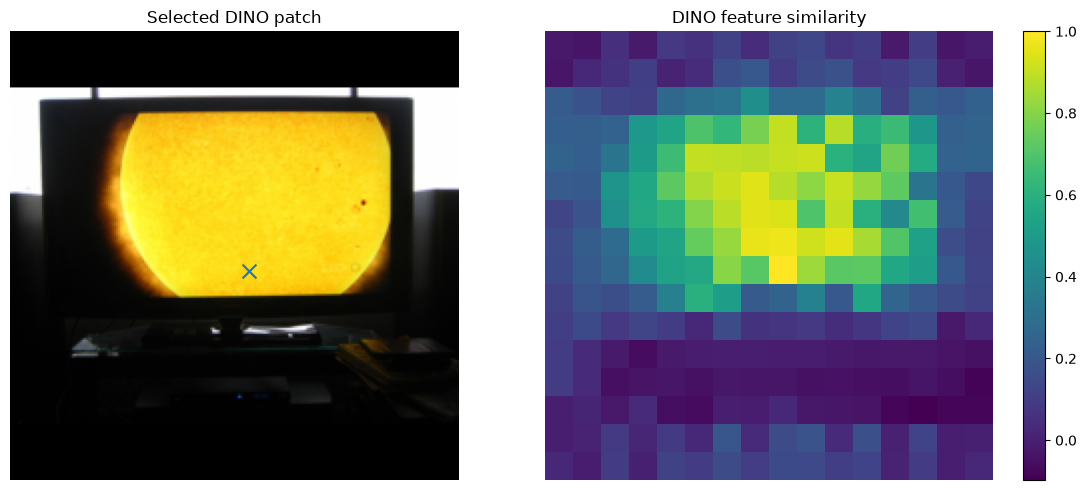

In [28]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(
    display_image
    .permute(1, 2, 0)
    .numpy()
)

axes[0].scatter(
    selected_col * 14 + 7,
    selected_row * 14 + 7,
    s=100,
    marker="x",
)

axes[0].set_title(
    "Selected DINO patch"
)

im = axes[1].imshow(
    similarity_map.numpy()
)

axes[1].set_title(
    "DINO feature similarity"
)

plt.colorbar(
    im,
    ax=axes[1],
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## DINOv2 Checkpoint

At this point we have verified that:

- the RGB image can be converted into valid DINOv2 input;
- DINOv2 ViT-S/14 is frozen;
- a 224 × 224 image produces 256 patch tokens;
- the tokens form a 16 × 16 spatial grid;
- every patch is represented using a 384-dimensional vector;
- similar image regions can have similar DINO representations.

The next step is to examine the text side independently using CLIP.

In [29]:
clip_model, _, _ = (
    open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai",
    )
)

clip_tokenizer = (
    open_clip.get_tokenizer(
        "ViT-B-32"
    )
)

clip_model = clip_model.to(DEVICE)
clip_model.eval()

for parameter in clip_model.parameters():
    parameter.requires_grad = False

print("CLIP loaded.")

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded.


In [30]:
query = sample["query"]

print("Raw query:", query)

Raw query: screen


In [31]:
prompt = (
    f"a photo of the "
    f"{query} of an object"
)

print("CLIP prompt:", prompt)

CLIP prompt: a photo of the screen of an object


In [32]:
text_tokens = clip_tokenizer(
    [prompt]
).to(DEVICE)

print(
    "Token tensor shape:",
    text_tokens.shape
)

Token tensor shape: torch.Size([1, 77])


In [33]:
with torch.no_grad():

    text_embedding = (
        clip_model.encode_text(
            text_tokens
        )
    )

text_embedding = F.normalize(
    text_embedding,
    dim=-1,
)

print(
    "Text embedding shape:",
    text_embedding.shape
)

Text embedding shape: torch.Size([1, 512])


In [34]:
print(
    text_embedding[
        0,
        :20
    ].cpu()
)

tensor([ 0.0027,  0.0497, -0.0376, -0.0194, -0.0068,  0.0331,  0.0219, -0.1085,
        -0.0027,  0.0391,  0.0270, -0.0423,  0.0198, -0.0026, -0.0074, -0.0016,
        -0.0056, -0.0079,  0.0015,  0.0052])


In [35]:
queries = [
    "wheel",
    "tire",
    "seat",
    "head",
    "leg",
    "wing",
    "tail",
    "body",
]

In [36]:
prompts = [
    f"a photo of the {q} of an object"
    for q in queries
]

for prompt in prompts:
    print(prompt)

a photo of the wheel of an object
a photo of the tire of an object
a photo of the seat of an object
a photo of the head of an object
a photo of the leg of an object
a photo of the wing of an object
a photo of the tail of an object
a photo of the body of an object


In [37]:
tokens = clip_tokenizer(
    prompts
).to(DEVICE)

with torch.no_grad():

    text_features = (
        clip_model.encode_text(
            tokens
        )
    )

text_features = F.normalize(
    text_features,
    dim=-1,
)

print(
    "Text features:",
    text_features.shape
)

Text features: torch.Size([8, 512])


In [38]:
text_similarity = (
    text_features
    @ text_features.T
)

print(
    text_similarity.shape
)

torch.Size([8, 8])


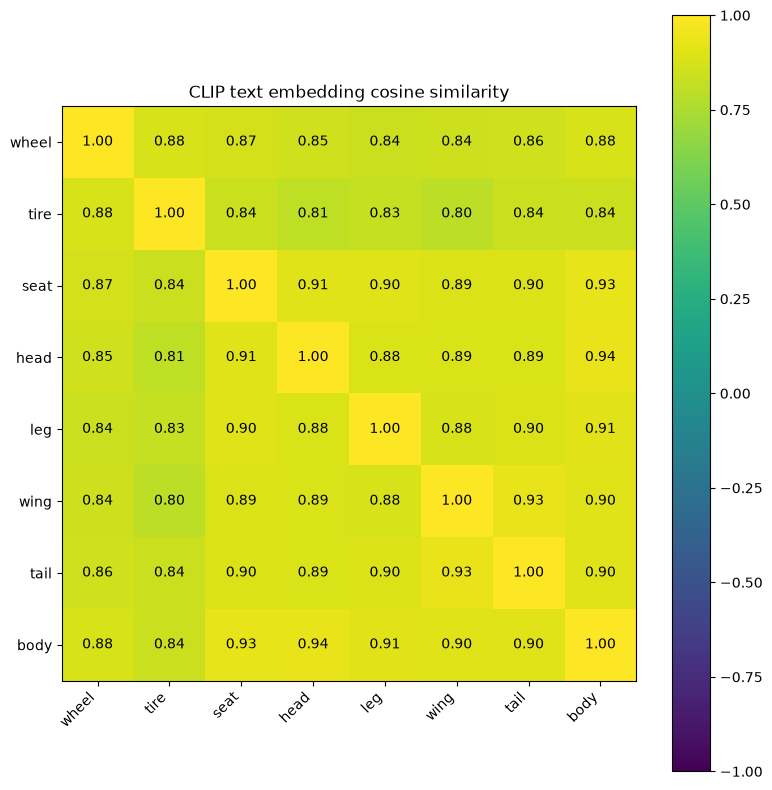

In [39]:
similarity_np = (
    text_similarity
    .detach()
    .cpu()
    .numpy()
)

fig, ax = plt.subplots(
    figsize=(8, 8)
)

im = ax.imshow(
    similarity_np,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(queries))
)

ax.set_yticks(
    range(len(queries))
)

ax.set_xticklabels(
    queries,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    queries
)

for i in range(len(queries)):
    for j in range(len(queries)):

        ax.text(
            j,
            i,
            f"{similarity_np[i,j]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title(
    "CLIP text embedding cosine similarity"
)

plt.colorbar(
    im,
    ax=ax,
)

plt.tight_layout()
plt.show()

In [40]:
object_specific_prompts = [
    "a photo of the wheel of a bicycle",
    "a photo of the wheel of a bus",
    "a photo of the wheel of a car",
    "a photo of the wheel of a motorbike",
]

tokens = clip_tokenizer(
    object_specific_prompts
).to(DEVICE)

with torch.no_grad():

    object_specific_features = (
        clip_model.encode_text(
            tokens
        )
    )

object_specific_features = F.normalize(
    object_specific_features,
    dim=-1,
)

object_similarity = (
    object_specific_features
    @ object_specific_features.T
)

object_similarity.cpu()

tensor([[1.0000, 0.9066, 0.9161, 0.9467],
        [0.9066, 1.0000, 0.9313, 0.8911],
        [0.9161, 0.9313, 1.0000, 0.9154],
        [0.9467, 0.8911, 0.9154, 1.0000]])

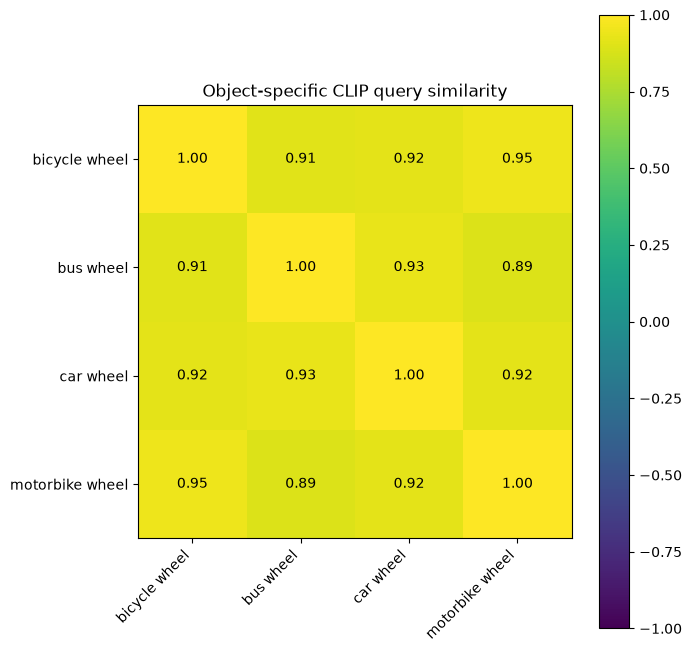

In [41]:
labels = [
    "bicycle wheel",
    "bus wheel",
    "car wheel",
    "motorbike wheel",
]

sim = (
    object_similarity
    .cpu()
    .numpy()
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

im = ax.imshow(
    sim,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(labels))
)

ax.set_yticks(
    range(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    labels
)

for i in range(len(labels)):
    for j in range(len(labels)):

        ax.text(
            j,
            i,
            f"{sim[i,j]:.2f}",
            ha="center",
            va="center",
        )

plt.colorbar(
    im,
    ax=ax,
)

ax.set_title(
    "Object-specific CLIP query similarity"
)

plt.tight_layout()
plt.show()

## DINOv2 versus CLIP

The two encoders are solving different representation problems.

### DINOv2

Input:

RGB image

Output:

[384, 16, 16]

It preserves spatial information.

Each spatial location describes one image region.

Conceptually:

> "What visually exists in this region?"

---

### CLIP Text Encoder

Input:

"wheel"

Output:

[512]

It does not produce a spatial map.

It produces one semantic representation for the entire text query.

Conceptually:

> "What semantic concept is being requested?"

---

Later our model must connect:

DINO spatial patch representations

with

CLIP semantic query representations.

That visual-language correspondence is one of the central challenges
of the project.

In [42]:
BATCH_SIZE = 8

samples = [
    dataset[i]
    for i in range(BATCH_SIZE)
]

In [43]:
batch_images = []

for s in samples:

    _, normalized, _ = (
        resize_and_pad_image(
            s["image"],
            target_size=IMAGE_SIZE,
        )
    )

    batch_images.append(
        normalized
    )

batch_images = torch.stack(
    batch_images
)

print(
    batch_images.shape
)

torch.Size([8, 3, 224, 224])


In [44]:
batch_images = batch_images.to(
    DEVICE
)

with torch.no_grad():

    outputs = dino.forward_features(
        batch_images
    )

batch_patch_tokens = outputs[
    "x_norm_patchtokens"
]

print(
    "Patch tokens:",
    batch_patch_tokens.shape
)

Patch tokens: torch.Size([8, 256, 384])


In [45]:
batch_dino_features = (
    batch_patch_tokens
    .transpose(1, 2)
    .reshape(
        BATCH_SIZE,
        384,
        16,
        16,
    )
)

print(
    "DINO feature map:",
    batch_dino_features.shape
)

DINO feature map: torch.Size([8, 384, 16, 16])


In [46]:
batch_queries = [
    s["query"]
    for s in samples
]

batch_prompts = [
    f"a photo of the {q} of an object"
    for q in batch_queries
]

print(batch_queries)

['screen', 'torso', 'leg', 'body', 'body', 'cap', 'headlight', 'front']


In [47]:
batch_text_tokens = (
    clip_tokenizer(
        batch_prompts
    )
    .to(DEVICE)
)

with torch.no_grad():

    batch_text_features = (
        clip_model.encode_text(
            batch_text_tokens
        )
    )

batch_text_features = F.normalize(
    batch_text_features,
    dim=-1,
)

print(
    "CLIP text features:",
    batch_text_features.shape
)

CLIP text features: torch.Size([8, 512])


In [48]:
print(
    "Images:"
)

print(
    batch_images.shape
)

print()

print(
    "DINO features:"
)

print(
    batch_dino_features.shape
)

print()

print(
    "CLIP text features:"
)

print(
    batch_text_features.shape
)

Images:
torch.Size([8, 3, 224, 224])

DINO features:
torch.Size([8, 384, 16, 16])

CLIP text features:
torch.Size([8, 512])


In [49]:
assert batch_images.shape == (
    BATCH_SIZE,
    3,
    224,
    224,
)

assert batch_dino_features.shape == (
    BATCH_SIZE,
    384,
    16,
    16,
)

assert batch_text_features.shape[0] == (
    BATCH_SIZE
)

assert batch_text_features.shape[1] == 512

assert not torch.isnan(
    batch_dino_features
).any()

assert not torch.isnan(
    batch_text_features
).any()

assert all(
    not p.requires_grad
    for p in dino.parameters()
)

assert all(
    not p.requires_grad
    for p in clip_model.parameters()
)

print(
    "All DINO/CLIP sanity checks passed."
)

All DINO/CLIP sanity checks passed.


In [50]:
if torch.cuda.is_available():

    print(
        "Allocated GPU memory:",
        round(
            torch.cuda.memory_allocated()
            / 1024**3,
            2,
        ),
        "GB",
    )

    print(
        "Reserved GPU memory:",
        round(
            torch.cuda.memory_reserved()
            / 1024**3,
            2,
        ),
        "GB",
    )

Allocated GPU memory: 0.67 GB
Reserved GPU memory: 0.78 GB


In [51]:
OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "dino_clip_features"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(OUTPUT_DIR)

/home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/dino_clip_features


In [52]:
import json

summary = {
    "image_size": IMAGE_SIZE,

    "dino_model": "dinov2_vits14",

    "dino_patch_size": 14,

    "dino_grid_size": 16,

    "dino_feature_dimension": 384,

    "clip_model": "ViT-B-32",

    "clip_pretrained": "openai",

    "clip_text_dimension": int(
        batch_text_features.shape[1]
    ),

    "dino_frozen": True,

    "clip_frozen": True,
}

summary_path = (
    OUTPUT_DIR
    / "feature_encoder_summary.json"
)

with open(
    summary_path,
    "w",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )

print(
    "Saved:",
    summary_path
)

Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/dino_clip_features/feature_encoder_summary.json


# Notebook 02 Summary

## DINOv2

The RGB image is resized and padded to:

224 × 224

DINOv2 ViT-S/14 divides the image into:

16 × 16 = 256 patches

Each patch is represented using:

384 features

Therefore:

Input:

[B, 3, 224, 224]

Output:

[B, 384, 16, 16]

DINOv2 is frozen.

---

## CLIP

Each part query is converted into a semantic text representation.

Example:

"wheel"

→ CLIP

→ 512-dimensional normalized embedding

Therefore:

Input:

B text queries

Output:

[B, 512]

CLIP is frozen.

---

## Important observation

DINO and CLIP currently live in different feature spaces:

DINO:
[B, 384, 16, 16]

CLIP:
[B, 512]

No learned correspondence between these spaces has been introduced yet.

The next notebook will build the simplest possible segmentation baseline
using these frozen representations.

No object-relative geometry has been introduced yet.